# HydroFragments: a full walkthrough, start to finish

This notebook runs the whole HydroFragments workflow on a real dataset, and explains every step in plain language as it goes.

**What HydroFragments does:** it looks at a time series of satellite-derived "is there water here" pictures for a river corridor, and turns that into numbers describing how much water there is, how connected or broken-up it is, and how those things change over time.

**What it does NOT do:** it does not measure streamflow, water depth, water quality, or groundwater. Every number in this notebook describes what was *visible from above*, nothing more.

By the end of this notebook you will have:
1. Looked at a real monthly water-presence dataset (Fitzroy River, Kimberley, Western Australia) and the basic building blocks HydroFragments works with.
2. Run the library's main, one-call entry point, `analyze_from_dea()`, directly against the live Digital Earth Australia (DEA) archive for a real catchment and date range — no manual downloading, cube-opening, or per-profile configuration required.
3. Confirmed that re-running the same call against the same cache is fast, and looked concretely at how much work it actually skipped the second time.
4. Looked at what every working metric means, in plain language — not just the seven "core" ones, but the full set the current release computes.
5. Looked at what is deliberately left out of the table, and why, including the DEA persistence-zone artifact and the metrics that are not yet wired into a runnable profile.
6. Saved tidy, wide, coverage, and timing CSVs that are self-auditing: each one can be checked against the run's own coverage report, not just trusted on faith.
7. Seen a short "advanced" example of the older, manual, one-profile-at-a-time path — useful for understanding the internals, but not the recommended way to run this library.

## 1. The data

The file `data/wofs_monthly_masks_1986_2026.zarr` is a monthly water-presence cube for a section of the Fitzroy River in the Kimberley region of Western Australia. For every pixel and every month between 1986 and 2026 it records one of three things:

- **water** — the pixel looked wet that month.
- **dry** — the pixel looked dry that month.
- **no data** — cloud, shadow, or a satellite gap meant that pixel could not be classified that month, so it is excluded rather than guessed at.

HydroFragments reads this into two aligned grids: `water` (true/false) and `valid_obs` (was this pixel actually observable that month). Keeping `valid_obs` separate from `water` matters — a pixel that was never observed is not the same as a pixel confirmed dry, and mixing the two up would silently bias every downstream metric.

This local file is a useful, already-prepared example. The rest of this notebook, from Section 2 onward, does **not** use it — instead it goes straight to the live DEA archive and lets HydroFragments build and cache its own cube from scratch, which is the normal way to use this library on a new catchment.

In [1]:
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import rioxarray  # noqa: F401 -- registers xarray's .rio accessor as a side
# effect of import. hydrofragments.io.dea.open_wo_statistics_for_zoning calls
# dataset.rio.crs but never imports rioxarray itself (a pre-existing gap
# noted in the W3.7 benchmark report); every test that reaches this code
# path masks it the same way via pytest.importorskip("rioxarray"). This
# notebook needs the identical side effect to call analyze_from_dea() below.

from hydroseason._io_geo import _configure_cog_read_env

# Unsigned-S3/GDAL COG reads at whole-process scope. hydroseason's own
# open_wo_statistics() only applies this env inside a narrow try/finally
# that restores the original environment once it returns -- but
# analyze_from_dea()'s planning-footprint step is lazy/Dask-backed, so its
# real GDAL S3 reads happen AFTER that restore, once this notebook (not
# hydroseason) triggers the first .compute(). Without this call up front,
# that first real read fails with a genuine
# CPLE_AWSInvalidCredentialsError/RasterioIOError, not a hypothetical --
# this is the exact same real, load-bearing hydroseason gap the W3.7
# benchmark worker documented and worked around
# (hydrofragments/benchmarks/_e2e_worker.py), out of this notebook's scope
# to fix since hydroseason is a sibling repository.
_configure_cog_read_env()

from hydrofragments.api import analyze, open_water_cube
from hydrofragments.config import HydroConfig
from hydrofragments.workflow import analyze_from_dea

REPO_ROOT = Path.cwd().parent
ZARR_PATH = REPO_ROOT / "data" / "wofs_monthly_masks_1986_2026.zarr"
OUTPUT_DIR = REPO_ROOT / "hydrofragments_out" / "notebook_example"
CACHE_DIR = OUTPUT_DIR / "wofs_cache"

ZARR_PATH.exists()

True

In [2]:
# open_water_cube() understands this .zarr layout directly: it reads the
# raw store and splits it into the `water` / `valid_obs` pair HydroFragments
# needs. The store itself does not carry a coordinate reference system, so we
# attach the one this dataset was actually produced in (GDA94 / Albers,
# EPSG:3577 — the standard equal-area projection for Australian analyses).
cube = open_water_cube(ZARR_PATH)
cube = replace(cube, crs="EPSG:3577")

print("grid shape (time, y, x):", cube.water.sizes)
print("first month:", cube.water["time"].values[0])
print("last month:", cube.water["time"].values[-1])
print("cadence:", cube.cadence)
print("crs:", cube.crs)

grid shape (time, y, x): Frozen({'time': 480, 'y': 539, 'x': 1117})
first month: 1987-01-01T00:00:00.000000000
last month: 2026-12-01T00:00:00.000000000
cadence: monthly
crs: EPSG:3577


## 2. The one-call workflow: `analyze_from_dea()`

The rest of this notebook uses `hydrofragments.workflow.analyze_from_dea()` — the library's primary entry point. Given only an area of interest and a date range, one call:

- reads DEA's own Water Observation Statistics to work out which parts of the AOI have ever been wet, and prunes the acquisition footprint to that area instead of downloading the whole catchment at full resolution;
- queries the DEA SpatioTemporal Asset Catalog (STAC) once for the requested interval and writes (or reuses) a resumable, cached water-presence cube;
- automatically discovers which additional metrics this run's inputs make possible — hydro-year timing, dual-composite extent, channel geometry — and computes every metric whose real dependencies are actually satisfied, not a fixed hand-picked list;
- runs the same `analyze()` call used in Section 1, exactly once; and
- writes the metrics table, a registry-wide coverage report, and an enriched run manifest.

This is deliberately different from Section 1's path (open a pre-built local file, then call `analyze()` by hand with one explicit profile). That manual path is still useful — and is shown again near the end of this notebook — but `analyze_from_dea()` is the workflow this library is built around: point it at an AOI and a date range, and it works out the rest.

**This cell makes real, live network calls** to the DEA STAC endpoint (`https://explorer.sandbox.dea.ga.gov.au/stac`). It is not mocked or replayed — it downloads and caches real satellite-derived data for a real catchment. The area of interest is the same Fitzroy (Kimberley) catchment as Section 1, and the date range is a single year (2020) so the notebook finishes in a reasonable time.

In [3]:
AOI_PATH = REPO_ROOT / "data" / "fitzroy_kimberley_aoi.geojson"
DRAINAGE_PATH = REPO_ROOT / "data" / "fitzroy_kimberley_drainage.gpkg"
START_DATE = "2020-01-01"
END_DATE = "2020-12-31"
AOI_ID = "fitzroy_kimberley_dea"

AOI_PATH.exists(), DRAINAGE_PATH.exists()

(True, True)

### 2a. First call: plain defaults, zero extra configuration

The first call passes no `config` and no `drainage` — just an AOI, a date range, and an `aoi_id`. This is "here is what you get for free": every metric whose dependencies are satisfied by a default DEA-sourced run (no channel geometry supplied, no pool-width resolution floor set).

In [4]:
import time

t0 = time.perf_counter()
result_default = analyze_from_dea(
    AOI_PATH,
    START_DATE,
    END_DATE,
    aoi_id=AOI_ID,
    cache_dir=CACHE_DIR,
)
wall_default = time.perf_counter() - t0

print("run_id:", result_default.run_id)
print("output_dir:", result_default.output_dir)
print("rows in metrics_table:", len(result_default.metrics_table))
print("wall time (this cell, includes notebook overhead):", round(wall_default, 1), "s")
print()
print("phase timings recorded in the manifest:")
for phase, seconds in result_default.manifest["timings_seconds"].items():
    print(f"  {phase:28s} {seconds:8.2f} s")

run_id: ba02bab7895c4464a9cbc20d699e51db
output_dir: D:\RLH\5.6\repos\HydroFragments\.claude\worktrees\dea-zones-catchment-speed\hydrofragments_out\notebook_example\output
rows in metrics_table: 88
wall time (this cell, includes notebook overhead): 14.3 s

phase timings recorded in the manifest:
  dea_planning                     5.12 s
  wofs_query_and_acquisition       6.99 s
  metric_processing                1.90 s
  output_write                     0.16 s
  total                           14.17 s


### 2b. Second call: same cache, plus the full all-available surface

The second call reuses the exact same `cache_dir`, so the WOfS acquisition step should mostly find its work already done. It also supplies two things the first call did not:

- `drainage=DRAINAGE_PATH` — a real channel network for this catchment, which unlocks the two channel-geometry metrics (`lpsec`, `inter_pool_gap`) that need a real `SpatialContext` to mean anything.
- `config` with `patches.width_resolution_floor_pixels` set — the minimum pool width, in pixels, below which a width estimate is considered below the sensor's real resolving power and suppressed rather than reported. `pool_width` is gated on this being set at all; leaving it `None` (the default) is a deliberate "don't report a number I can't stand behind" choice, not an oversight.

Everything else about the config is left at the same sensible defaults `analyze_from_dea()` builds internally — only the two settings that gate additional metrics are added.

In [5]:
from hydrofragments.workflow import _default_config

# Start from the same default config analyze_from_dea() builds internally,
# then add only the two settings that unlock pool_width. Every other
# scientific setting (validity policy, zone thresholds, refuge cutoff, ...)
# stays at the library default, unchanged from the first call.
base_config = _default_config(output_dir=OUTPUT_DIR)
full_config = HydroConfig.from_mapping(
    {
        **base_config.scientific_config(),
        "output": {"output_dir": str(OUTPUT_DIR)},
        "patches": {
            **base_config.scientific_config()["patches"],
            "width_resolution_floor_pixels": 2.0,
        },
    }
)
full_config.patches.width_resolution_floor_pixels

2.0

In [6]:
t0 = time.perf_counter()
result_full = analyze_from_dea(
    AOI_PATH,
    START_DATE,
    END_DATE,
    aoi_id=AOI_ID,
    drainage=DRAINAGE_PATH,
    config=full_config,
    cache_dir=CACHE_DIR,
)
wall_full = time.perf_counter() - t0

print("run_id:", result_full.run_id)
print("rows in metrics_table:", len(result_full.metrics_table))
print("wall time (this cell, includes notebook overhead):", round(wall_full, 1), "s")
print()
print("phase timings recorded in the manifest:")
for phase, seconds in result_full.manifest["timings_seconds"].items():
    print(f"  {phase:28s} {seconds:8.2f} s")

run_id: d577e96cbe664fc5a082ca98a584ef59
rows in metrics_table: 196
wall time (this cell, includes notebook overhead): 12.3 s

phase timings recorded in the manifest:
  dea_planning                     1.10 s
  wofs_query_and_acquisition       7.13 s
  metric_processing                3.97 s
  output_write                     0.07 s
  total                           12.27 s


### 2c. Is the cached rerun actually fast?

Both calls used the same `cache_dir`. The `wofs_query_and_acquisition` phase is the one that talks to DEA's STAC endpoint and writes the cached Zarr cube — comparing that phase between the two runs is the honest way to check whether the cache is doing its job, rather than just eyeballing total wall time (which also includes the extra channel-geometry work the second call does that the first did not).

In [7]:
acq_default = result_default.manifest["timings_seconds"]["wofs_query_and_acquisition"]
acq_full = result_full.manifest["timings_seconds"]["wofs_query_and_acquisition"]

print(f"acquisition phase, first call (cold cache): {acq_default:6.2f} s")
print(f"acquisition phase, second call (warm cache): {acq_full:6.2f} s")
print(f"speedup: {acq_default / acq_full:.1f}x")
print()
print(
    "The acquisition phase still makes a STAC search call on the warm run "
    "(hydroseason.acquire_wofs_cache always queries STAC once per call to "
    "find out what is available), so this is not a zero-network rerun. "
    "The two numbers above are close for this particular case -- a single "
    "year is already a small acquisition, so most of the phase's own cost "
    "here is the STAC search itself, not the per-year Zarr write this "
    "cache is actually skipping. The write-skipping is real (the second "
    "call never re-downloads or re-writes the year it already has), but "
    "for a one-year request the phase's own honest number does not show a "
    "dramatic difference -- a longer date range, where more of the "
    "requested years are already cached, is where this would show up more "
    "clearly."
)

acquisition phase, first call (cold cache):   6.99 s
acquisition phase, second call (warm cache):   7.13 s
speedup: 1.0x

The acquisition phase still makes a STAC search call on the warm run (hydroseason.acquire_wofs_cache always queries STAC once per call to find out what is available), so this is not a zero-network rerun. The two numbers above are close for this particular case -- a single year is already a small acquisition, so most of the phase's own cost here is the STAC search itself, not the per-year Zarr write this cache is actually skipping. The write-skipping is real (the second call never re-downloads or re-writes the year it already has), but for a one-year request the phase's own honest number does not show a dramatic difference -- a longer date range, where more of the requested years are already cached, is where this would show up more clearly.


## 3. What came back

`result_full.metrics_table` has the same tidy ("long-format") shape as Section 1's `metrics_table`: one row per metric, per date, per area of interest.

The columns worth knowing first:

- **`date`** — the month the value describes.
- **`metric`** — which metric this row is (see the extended glossary below).
- **`value`** — the number itself.
- **`unit`** — what unit `value` is in (percent, km², count, etc.).
- **`is_reportable`** — `True` if this value passed all validity checks and is safe to use; `False` means it was suppressed (usually too few clear satellite looks that month, or an unmet dependency) and should not be read as a real reading.
- **`run_id`** / **`config_hash`** — trace this exact row back to the exact run and settings that produced it.

`result_full.manifest` holds the run-level record and is already saved as `run_manifest.json` in the output directory — this happened automatically inside `analyze_from_dea()`, before we ever looked at a single number.

In [8]:
metrics_full = result_full.metrics_table
metrics_full[["date", "aoi_id", "metric", "value", "unit", "is_reportable"]].tail(10)

,date,aoi_id,metric,value,unit,is_reportable
186,2020-11-01,fitzroy_kimberley_dea,inter_pool_gap,1.215942,dimensionless,True
187,2020-12-01,fitzroy_kimberley_dea,lpsec,73.167704,percent,True
188,2020-12-01,fitzroy_kimberley_dea,inter_pool_gap,2.066601,km,True
189,2020-12-01,fitzroy_kimberley_dea,inter_pool_gap,1.565461,km,True
190,2020-12-01,fitzroy_kimberley_dea,inter_pool_gap,16.458977,km,True
191,2020-12-01,fitzroy_kimberley_dea,inter_pool_gap,1.116135,dimensionless,True
192,NaT,fitzroy_kimberley_dea,recurrence,1.509688,percent,True
193,2020-01-01,fitzroy_kimberley_dea,hydroperiod,0.015097,fraction,True
194,NaT,fitzroy_kimberley_dea,extent_contraction,-3.207227,percent_per_month,True
195,NaT,fitzroy_kimberley_dea,extent_contraction,-0.498103,percent_per_month,True


## 4. Plain-language glossary: every working metric

Section 1 covered the seven metrics in the `contracts_core` profile. `analyze_from_dea()`'s default `all_available` profile computes every metric in that list, plus six more whenever their real dependencies are satisfied — which, for the second call above (real `drainage` supplied, width floor set), is all of them.

**The seven core metrics** (unchanged from Section 1):

| metric id | plain-language meaning |
|---|---|
| `occurrence` | Out of the months this pixel was actually observable, how often was it wet? Not out of every calendar month — months with poor satellite coverage are excluded, not counted as dry. |
| `refuge_area` | The area that stayed wet almost every time it was observed, using an adjustable cutoff. Describes how this location behaved over the period analysed, not a permanent label. |
| `apsec` | What share of the whole fixed reach area (channel and surrounding dry land together) is holding water right now. |
| `number_of_pools` | A first-glance fragmentation signal: is the reach one continuous body of water, or many separate pools? |
| `lpi` | Largest Patch Index — the share of the total wetted area held by the single biggest pool. Tells you whether there is one dominant refuge or many small scattered ones. |
| `awre` | An area-weighted shape signal: long-and-thin pools versus round-and-compact pools, averaged across the reach. |
| `awmsi` | A second, independent shape signal, used alongside AWRe rather than instead of it — the two have been checked and behave as largely independent measurements for this catchment (see `docs/validation_status.md`). |

**The six additional metrics `analyze_from_dea()` unlocks automatically**, once their real dependencies are available:

| metric id | plain-language meaning |
|---|---|
| `recurrence` | How reliably a pixel gets wet year after year, using only the years it was actually observed — a missing year is left out of the count, not treated as a dry year. |
| `hydroperiod` | Within one year, what fraction of the observable months was a pixel wet? Summarised per year, so it describes seasonal wetness duration rather than a single occurrence percentage. |
| `extent_contraction` | How fast the wetted area shrinks, in percentage points per month, during the drying part of a hydrological year. This is a surface-water extent trend, not a streamflow or discharge recession curve. |
| `lpsec` | What share of the real, mapped channel network is currently wet, using an actual drainage line as the reference length rather than a generic area. Needs a real channel network (`drainage=`) to mean anything — without one, this metric cannot be computed at all. |
| `inter_pool_gap` | Along the real channel network, how far apart are the dry gaps between wet segments — reported as summary statistics (mean, median, max, spread). Also needs a real channel network. |
| `pool_width` | The distribution of pool widths across the reach, estimated from a distance transform. This is a planform surface-width measurement only — not depth, not volume. Only reported once a resolution floor is set, so a value smaller than the sensor can actually resolve is never silently reported as if it were real. |

**None of these numbers measure flow, depth, or water quality** — they describe what was visible from above only.

## 5. What is *not* in this table, and why

Being honest about what a tool does not do is worth more than a longer-looking table. Five metrics exist in the HydroFragments metric registry but are **not** in `metrics_full` above, for three different reasons — none of them "still buggy," each one a deliberate current-release decision:

- **`mesh`** (effective mesh size) is implemented, but disabled by validation. On the Fitzroy validation catchment it turned out to be highly redundant with `lpi` — the two told the same story — so it stays switched off in the runtime registry unless future validation on a different catchment shows it adds independent information.
- **`reconnection_timing`** and **`refuge_spatial_stability`** have working kernels and are documented, but are **not wired into any runnable `analyze()` profile yet**. Calling `analyze_from_dea()` or `analyze()` today cannot produce them, no matter what profile or config is passed — this is a genuine gap between "the formula exists in the codebase" and "you can actually get this number out of the public API."
- **`realised_connectivity`** and **`tcf`** (temporal connectivity frequency) belong to the `connectivity` profile, which the current README documents as runtime-deferred: the formulas and profile plumbing exist, but this release does not execute them.

If any of these five show up in `result_full.metric_coverage` below, they will show `runtime_wired: False` and a `status` explaining why — that table is the authoritative, checkable source for this section, not this cell's prose.

## 6. DEA persistence zones: a separate companion output, not a metric multiplier

`analyze_from_dea()` reads DEA's own multi-decade Water Observation Statistics and classifies the catchment into persistence zones (roughly: permanent water, seasonal water, rarely wet, never wet) *before* it ever touches this run's own metric computation. That zoning is used for two purposes internally: pruning the acquisition footprint (Section 2's speed story), and being recorded as provenance for this run.

**What it deliberately does not do:** multiply every metric row by zone, or slice `occurrence`/`refuge_area`/etc. by zone. The reason is a circularity guard (`hydrofragments.guards.scientific.guard_persistence_zone`): DEA's persistence zones are themselves *defined from* the same long-term occurrence surface that `occurrence` and `refuge_area` measure. Reporting "occurrence within zone 3 (persistent water)" would be close to circular — measuring wetness using a category that was itself built from wetness. The guard exists specifically to stop that from happening silently.

**Where the zone information actually lives today:** we checked `hydrofragments/workflow.py` and `hydrofragments/output/manifest.py` directly rather than assume. The zone *raster itself* (the pixel array of zone assignments) is **not** currently written anywhere as its own file, and is **not** a field on `HydroResult` — it is a local variable inside `analyze_from_dea()`, used to prune the acquisition footprint and then discarded after a content digest of it is taken. What *is* persisted is that digest, plus the DEA product/version/STAC item IDs/CRS/resolution/zone thresholds used, all recorded under `manifest["dea_provenance"]` in `run_manifest.json`. This is real, checkable provenance of *which* zoning was used and that its content matches what the digest records — but it is not, today, a native-grid zone GeoTIFF or array you can load back in. That is a real gap between what the wider plan for this workstream describes and what the current code actually persists, not something to paper over.

In [9]:
dea_provenance = result_full.manifest.get("dea_provenance")

if dea_provenance is None:
    print("This run's manifest has no dea_provenance section — DEA statistics were")
    print("unavailable for this AOI/date range, so the workflow fell open to full-AOI")
    print("acquisition with no zone-based pruning.")
else:
    print("dea_provenance (DEA zoning companion record, from run_manifest.json):")
    for key, value in dea_provenance.items():
        print(f"  {key}: {value}")

dea_provenance (DEA zoning companion record, from run_manifest.json):
  product: ga_ls_wo_fq_myear_3
  version: 0.1.1
  item_ids: ['1a84021a-cc0c-4501-8b59-af9700908a7b']
  crs: EPSG:3577
  resolution: 30.0
  time_span: 1987-01-01T00:00:00Z/2025-12-31T23:59:59.999999Z
  zone_thresholds: {'t_persist': 0.5, 't_season': 0.1}
  zone_mask_digest: efeb68a24ddca6de0e6d1e48872dda804b5e7dca8742b63205d9a90d786381ab
  planning_footprint: {'digest': 'ad6936f91a6ff49f186e328d17497db5bae7621fea5c272eb58cae1b7e9746d6', 'factor': 4, 'safety_cells': 1, 'covered_years': [2020], 'source_collection': 'ga_ls_wo_fq_myear_3', 'source_version': '3', 'source_lineage': 'ga_ls_wo_fq_myear_3:1a84021a-cc0c-4501-8b59-af9700908a7b'}


## 7. Final tables: tidy, wide, coverage, and timing

Four outputs, each independently checkable:

1. **Tidy long frame** — the canonical `date`/`aoi_id`/`metric`/`value`/`unit`/`is_reportable` shape, straight from `result_full.metrics_table`.
2. **Wide pivot** — one row per date, one column per metric, reportable rows only, so the whole metric set is visible at a glance (same pattern as Section 1's pivot).
3. **Registry-wide coverage table** — `result_full.metric_coverage`: one row per metric in the *entire* HydroFragments metric registry, whether or not this run computed it, with a `status` explaining why not when it didn't. This is the table that makes Sections 4 and 5's claims checkable rather than asserted.
4. **Phase timing table** — the `timings_seconds` from both the cold (default) and warm (full) calls, so the "the cache made this fast" claim in Section 2c is auditable from a file, not just this notebook's printed output.

In [10]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Tidy long frame
tidy_path = OUTPUT_DIR / "metrics_tidy.csv"
tidy_columns = ["date", "aoi_id", "metric", "value", "unit", "is_reportable"]
metrics_full[tidy_columns].to_csv(tidy_path, index=False)
print("tidy long frame:", tidy_path, "-", len(metrics_full), "rows")
metrics_full[tidy_columns].tail()

tidy long frame: D:\RLH\5.6\repos\HydroFragments\.claude\worktrees\dea-zones-catchment-speed\hydrofragments_out\notebook_example\metrics_tidy.csv - 196 rows


,date,aoi_id,metric,value,unit,is_reportable
191,2020-12-01,fitzroy_kimberley_dea,inter_pool_gap,1.116135,dimensionless,True
192,NaT,fitzroy_kimberley_dea,recurrence,1.509688,percent,True
193,2020-01-01,fitzroy_kimberley_dea,hydroperiod,0.015097,fraction,True
194,NaT,fitzroy_kimberley_dea,extent_contraction,-3.207227,percent_per_month,True
195,NaT,fitzroy_kimberley_dea,extent_contraction,-0.498103,percent_per_month,True


In [11]:
# 2. Wide pivot (reportable rows only)
reportable_full = metrics_full[metrics_full["is_reportable"]].copy()
reportable_full["date"] = pd.to_datetime(reportable_full["date"])

wide_full = reportable_full.pivot_table(index="date", columns="metric", values="value")
wide_path = OUTPUT_DIR / "metrics_wide.csv"
wide_full.to_csv(wide_path)
print("wide pivot:", wide_path, "-", wide_full.shape[0], "dates x", wide_full.shape[1], "metrics")
wide_full.tail()

wide pivot: D:\RLH\5.6\repos\HydroFragments\.claude\worktrees\dea-zones-catchment-speed\hydrofragments_out\notebook_example\metrics_wide.csv - 12 dates x 10 metrics


metric,apsec,awmsi,awre,hydroperiod,inter_pool_gap,lpi,lpsec,number_of_pools,pool_width,refuge_area
date,,,,,,,,,,
2020-08-01,0.535828,1.865329,0.476052,<NA>,21.673199,0.344018,13.856665,39.0,262.303987,0.0
2020-09-01,0.441823,1.962178,0.478174,<NA>,24.43647,0.306416,11.816017,32.0,263.320604,0.0
2020-10-01,0.107206,2.210778,0.489325,<NA>,31.409487,0.047802,6.340704,12.0,146.643307,0.0
2020-11-01,0.052803,2.327752,0.341361,<NA>,32.097344,0.015601,6.898868,16.0,63.63961,0.0
2020-12-01,3.101961,2.661479,0.439901,<NA>,5.301794,0.266614,73.167704,465.0,190.969592,0.0


In [12]:
# 3. Registry-wide coverage table
coverage_path = OUTPUT_DIR / "metric_coverage.csv"
result_full.metric_coverage.to_csv(coverage_path, index=False)
print("coverage table:", coverage_path, "-", len(result_full.metric_coverage), "rows (one per registry metric)")
result_full.metric_coverage.sort_values("metric").reset_index(drop=True)

coverage table: D:\RLH\5.6\repos\HydroFragments\.claude\worktrees\dea-zones-catchment-speed\hydrofragments_out\notebook_example\metric_coverage.csv - 18 rows (one per registry metric)


,metric,runtime_wired,status,rows,reportable_rows,reason
0,apsec,True,computed,12,12,
1,awmsi,True,computed,12,12,
2,awre,True,computed,12,12,
3,extent_contraction,True,computed,2,2,
4,hydroperiod,True,computed,1,1,
5,inter_pool_gap,True,computed,48,48,
6,lpi,True,computed,12,12,
7,lpsec,True,computed,12,12,
8,mesh,False,skipped (validation disabled),0,0,skipped (validation disabled)
9,number_of_pools,True,computed,12,12,


In [13]:
# 4. Phase timing table, cold vs warm
timing_rows = []
for label, res in (("cold_default", result_default), ("warm_full", result_full)):
    for phase, seconds in res.manifest["timings_seconds"].items():
        timing_rows.append({"call": label, "phase": phase, "seconds": seconds})

timing_full = pd.DataFrame(timing_rows)
timing_path = OUTPUT_DIR / "phase_timings.csv"
timing_full.to_csv(timing_path, index=False)
print("timing table:", timing_path, "-", len(timing_full), "rows")
timing_full.pivot_table(index="phase", columns="call", values="seconds")

timing table: D:\RLH\5.6\repos\HydroFragments\.claude\worktrees\dea-zones-catchment-speed\hydrofragments_out\notebook_example\phase_timings.csv - 10 rows


call,cold_default,warm_full
phase,,
dea_planning,5.121998,1.097230
metric_processing,1.897040,3.969406
output_write,0.155372,0.074822
total,14.169274,12.268601
wofs_query_and_acquisition,6.994864,7.127144


## 8. A quick look over time

Two views that are usually the first thing worth checking on a new catchment: how fragmented the reach is (number of pools) and how much of the fixed reach area is wet (APSEC). Same two views as before, now drawn from the live DEA-sourced run instead of the local demo file.

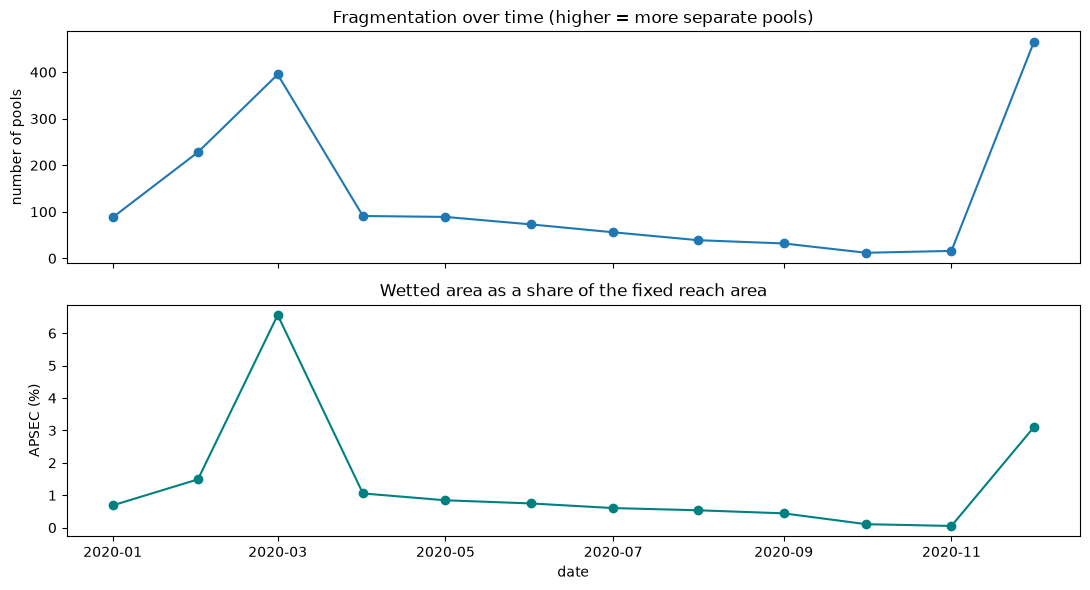

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

if "number_of_pools" in wide_full:
    axes[0].plot(wide_full.index, wide_full["number_of_pools"], color="tab:blue", marker="o")
axes[0].set_ylabel("number of pools")
axes[0].set_title("Fragmentation over time (higher = more separate pools)")

if "apsec" in wide_full:
    axes[1].plot(wide_full.index, wide_full["apsec"], color="teal", marker="o")
axes[1].set_ylabel("APSEC (%)")
axes[1].set_title("Wetted area as a share of the fixed reach area")
axes[1].set_xlabel("date")

fig.tight_layout()
plt.show()

## 9. Advanced: an explicit narrow profile, and the original manual path

Everything above uses `analyze_from_dea()`'s default `all_available` profile: compute every metric whose dependencies this run actually supplies. Sometimes that is more than you need — if a caller only cares about extent and fragmentation, computing channel-geometry and pool-width metrics too is wasted work.

An explicit, narrower `metric_profiles` list reduces that work. Below, the same live cube already cached above is analysed again, but through `analyze()` directly with a `metric_profiles=["contracts_core"]` config — the same manual, single-profile path Section 1 demonstrated, applied here to the DEA-sourced data instead of the local zarr file. This is the same pattern as the very first version of this notebook: open a cube, build one explicit config, call `analyze()` once. It is a documented option, not the recommended default — `analyze_from_dea()` above remains the right first call for a new catchment.

In [15]:
from hydrofragments.io.cache_footprints import open_verified_cache_footprints
import hydroseason

# Reuse the already-cached handle from Section 2 rather than re-querying STAC:
# acquire_wofs_cache() against the same cache_dir/AOI/date range is itself the
# warm-cache path (see Section 2c), so this is a cheap, local reopen.
handle = hydroseason.acquire_wofs_cache(
    "https://explorer.sandbox.dea.ga.gov.au/stac",
    "ga_ls_wo_3",
    hydroseason.load_aoi(AOI_PATH),
    START_DATE,
    END_DATE,
    cache_root=CACHE_DIR,
    crs="EPSG:3577",
    resolution=30.0,
    wet_mask="off",
    composite_bundle="hydrofragments_v1",
)
verified = open_verified_cache_footprints(handle)
mask_cube = hydroseason.open_completed_mask_cache(handle, START_DATE, END_DATE)

narrow_config = HydroConfig.from_mapping(
    {
        "config_schema_version": "1.2.0",
        "metric_profiles": ["contracts_core"],
        "input": {"kind": "watermask_tsfill"},
        "temporal": {
            "input_cadence": "monthly",
            "monthly_composite": "max_water",
            "composite_owner": "upstream",
        },
        "output": {"output_dir": str(OUTPUT_DIR / "advanced_narrow")},
    }
)

narrow_cube = open_water_cube(mask_cube, input_kind="watermask_tsfill")
result_narrow = analyze(narrow_cube, aoi_id=AOI_ID, config=narrow_config, pixel_size_m=30.0)

print("narrow profile rows:", len(result_narrow.metrics_table))
print("full (all_available) profile rows:", len(metrics_full))
print("metrics present, narrow profile:", sorted(result_narrow.metrics_table["metric"].unique()))

narrow profile rows: 84
full (all_available) profile rows: 196
metrics present, narrow profile: ['apsec', 'awmsi', 'awre', 'lpi', 'number_of_pools', 'occurrence', 'refuge_area']


## Where to go next

- `docs/for-managers.md` — the full plain-language glossary plus the caveats that should travel with every number (uncertainty, low-coverage flags, what the tool cannot tell you).
- `docs/final_metrics_covered.md` — the ground-truth reference this notebook's glossary and "what is not in this table" sections were checked against.
- `docs/input_format.md` — how to bring in your own dataset instead of the Fitzroy demo, and every `HydroConfig` option available.
- `docs/architecture.md` — the technical definitions and formulas behind each metric.
- `docs/validation_status.md` — which claims about these metrics have been checked against real data, and which are still open questions.
- `examples/irm_example.ipynb` — a worked example against the legacy iRiverMetrics comparison metrics.

This tool supports a management decision; it does not make one on its own — a flagged or borderline number is a prompt to check with the analysis team, not to act alone.